#### SUPERVISED LEARNING HANDS-ON PROJECT
Customer Churn Prediction – Messy Real-World Dataset


#### 1. Understand the Problem


The target variable is Churn.

It tells us whether a customer has churned or not:

Yes = Customer churned

No =! Customer did not churn


#### Numerical Columns

- Age
- Annual_Income
- Tenure_Months
- Monthly_Charges
- Support_Calls_Last_3M
- Data_Usage_GB
- Satisfaction_Score

#### Categorical Columns

- Contract_Type
- Payment_Method
- Region
- Plan_Type

## Identifier Column

-"Customer_ID"

"Customer_ID" is an identifier used to identify each customer. It will not be used as a feature for prediction.

## Problem Type

This is a "classification problem" because the target variable  Churn" contains two categories: "Yes" and "No".

The goal is to predict whether a customer will churn or not.

#### 2. Import and initial inspection



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Calibo\Supervised learning use case\Supervised_Learning_Messy_Customer_Churn.csv")
df

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes


In [3]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]
numerical_columns


['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [4]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]
categorical_columns

['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

In [5]:
identifier_columns = [
    "Customer_ID"
]
identifier_columns

['Customer_ID']

In [6]:
target_variable = "Churn"

target_variable

'Churn'

In [7]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [8]:
df.tail()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


In [9]:
df.shape

(184, 13)

In [10]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='str')

In [11]:
for col in df.columns:
    print(repr(col))

'Customer_ID'
'Age'
'Annual_Income'
'Tenure_Months'
'Monthly_Charges'
'Support_Calls_Last_3M'
'Data_Usage_GB'
'Satisfaction_Score'
'Contract_Type'
'Payment_Method'
'Region'
'Plan_Type'
'Churn'


In [12]:
df.dtypes

Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    str    
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    str    
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    str    
 9   Payment_Method         184 non-null    str    
 10  Region                 184 non-null    str    
 11  Plan_Type              184 non-null    str    
 12  Churn                  184 non-null    str    
dtypes: float64(6), str(7)
memory usage: 27.0 KB


In [14]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [15]:
(df.isnull().sum() / len(df)) * 100

Customer_ID              0.000000
Age                      4.347826
Annual_Income            5.978261
Tenure_Months            3.804348
Monthly_Charges          3.260870
Support_Calls_Last_3M    2.717391
Data_Usage_GB            3.260870
Satisfaction_Score       3.260870
Contract_Type            0.000000
Payment_Method           0.000000
Region                   0.000000
Plan_Type                0.000000
Churn                    0.000000
dtype: float64

In [16]:
df.duplicated().sum()

np.int64(4)

In [17]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 4


In [18]:
df_cleaned = df.drop_duplicates().copy()

In [19]:
print("Number of duplicate rows after removal:", df_cleaned.duplicated().sum())

Number of duplicate rows after removal: 0


In [20]:
print("Original shape:", df.shape)
print("Shape after removing duplicates:", df_cleaned.shape)

Original shape: (184, 13)
Shape after removing duplicates: (180, 13)


In [21]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,150.000000,999.000000,30.000000,44.000000,15.000000


In [22]:
df.describe(include='object')

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_27884\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Customer_ID,Annual_Income,Contract_Type,Payment_Method,Region,Plan_Type,Churn
count,184,173,184,184,184,184,184
unique,180,156,8,9,8,6,2
top,CUST-1043,76600.0,Monthly,Bank Transfer,South,Standard,Yes
freq,2,4,104,48,50,93,97


In [23]:
print(df.columns.tolist())

['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [24]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='str')

#### Checking Target Distribution

In [25]:
df["Churn"].value_counts()


Churn
Yes    97
No     87
Name: count, dtype: int64

In [26]:
df["Churn"].value_counts(normalize=True) * 100

Churn
Yes    52.717391
No     47.282609
Name: proportion, dtype: float64

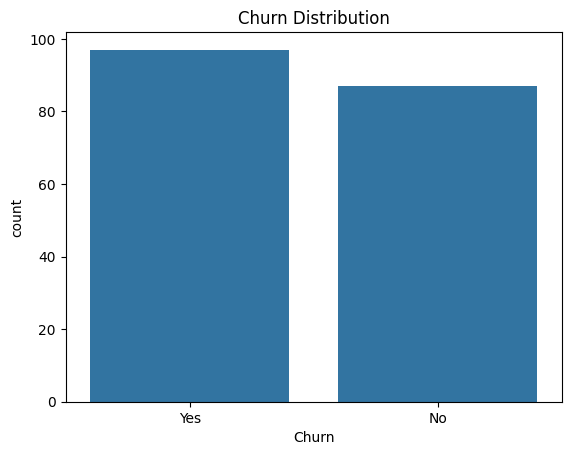

In [27]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

#### Checking Suspicious categorical values

In [28]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [29]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [30]:
df["Plan_Type"].value_counts()

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [31]:
df["Annual_Income"].unique()

<ArrowStringArray>
[ '23800.0',  '69400.0',        nan,  '80000.0',  '95700.0',  '88000.0',
  '49100.0',  '69200.0',  '43300.0',  '59800.0',
 ...
  '54200.0',  '37900.0',  '71300.0',  '79200.0', '100400.0',  '54100.0',
  '63000.0',  '45300.0',  '47100.0',  '48300.0']
Length: 157, dtype: str

In [32]:
df[[
    "Age",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]].agg(["min", "max"])

,Age,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
min,-5.0,1.0,0.0,0.0,-10.0,1.0
max,145.0,150.0,999.0,30.0,44.0,15.0


#### 3.Data Cleaning

In [33]:
df_cleaned = df.copy()

In [34]:
df_cleaned = df_cleaned.replace(["?", "NA", "N/A"], np.nan)

In [35]:
df_cleaned.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             1
Payment_Method            1
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

In [36]:
df_cleaned.duplicated().sum()

np.int64(4)

In [37]:
df_cleaned[df_cleaned.duplicated(keep=False)].sort_values("Customer_ID")

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [38]:
df_cleaned = df_cleaned.drop_duplicates()

In [39]:
df_cleaned = df_cleaned.drop_duplicates()


In [40]:
df_cleaned["Annual_Income"] = pd.to_numeric(
    df_cleaned["Annual_Income"],
    errors="coerce"
)

In [41]:
df_cleaned["Annual_Income"].describe()

count    1.680000e+02
mean     1.234518e+05
std      7.669285e+05
min     -1.200000e+04
25%      4.900000e+04
50%      6.440000e+04
75%      7.820000e+04
max      9.999999e+06
Name: Annual_Income, dtype: float64

In [42]:
df_cleaned.loc[df_cleaned["Annual_Income"] < 0, "Annual_Income"] = np.nan

df_cleaned.loc[df_cleaned["Annual_Income"] > 200000, "Annual_Income"] = np.nan

In [43]:
df_cleaned["Age"].sort_values().unique()

array([ -5.,  10.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,  24.,
        25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,
        36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,
        47.,  48.,  49.,  50.,  51.,  52.,  55.,  58.,  61.,  63., 145.,
        nan])

In [44]:
df_cleaned.loc[
    (df_cleaned["Age"] < 18) | (df_cleaned["Age"] > 100),
    "Age"
] = np.nan

In [45]:
df_cleaned["Tenure_Months"].describe()

count    173.000000
mean      39.300578
std       21.499104
min        1.000000
25%       25.000000
50%       38.000000
75%       54.000000
max      150.000000
Name: Tenure_Months, dtype: float64

In [46]:
df_cleaned.loc[
    df_cleaned["Tenure_Months"] > 100,
    "Tenure_Months"
] = np.nan

In [47]:
df_cleaned.loc[
    df_cleaned["Monthly_Charges"] > 200,
    "Monthly_Charges"
] = np.nan

In [48]:
df_cleaned.loc[
    df_cleaned["Support_Calls_Last_3M"] > 20,
    "Support_Calls_Last_3M"
] = np.nan

In [49]:
df_cleaned.loc[
    df_cleaned["Data_Usage_GB"] < 0,
    "Data_Usage_GB"
] = np.nan

In [50]:
df_cleaned.loc[
    (df_cleaned["Satisfaction_Score"] < 1) |
    (df_cleaned["Satisfaction_Score"] > 10),
    "Satisfaction_Score"
] = np.nan

In [51]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

In [52]:
for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].str.strip()

In [53]:
for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].str.title()

In [54]:
df_cleaned["Contract_Type"] = df_cleaned["Contract_Type"].replace({
    "2-Year": "2 Year"
})

In [55]:
df_cleaned["Contract_Type"].value_counts(dropna=False)

Contract_Type
Monthly    103
1 Year      52
2 Year      24
NaN          1
Name: count, dtype: int64

In [56]:
df_cleaned["Payment_Method"] = df_cleaned["Payment_Method"].replace({
    "Upi": "UPI"
})

In [57]:
for column in categorical_columns:
    print("\n", column)
    print(df_cleaned[column].value_counts(dropna=False))


 Contract_Type
Contract_Type
Monthly    103
1 Year      52
2 Year      24
NaN          1
Name: count, dtype: int64

 Payment_Method
Payment_Method
UPI              47
Bank Transfer    46
Credit Card      44
Debit Card       41
NaN               1
Unknown           1
Name: count, dtype: int64

 Region
Region
North    50
South    49
West     46
East     34
NaN       1
Name: count, dtype: int64

 Plan_Type
Plan_Type
Standard    94
Basic       47
Premium     39
Name: count, dtype: int64


In [58]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

In [59]:
for column in numerical_columns:
    df_cleaned[column] = df_cleaned[column].fillna(
        df_cleaned[column].median()
    )

In [60]:
for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].fillna(
        df_cleaned[column].mode()[0]
    )

In [61]:
df_cleaned.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [62]:
df_cleaned.to_csv("cleaned_dataset.csv", index=False)

In [63]:
df_cleaned.duplicated().sum()

np.int64(0)

In [64]:
df_cleaned.dtypes

Customer_ID                  str
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

In [65]:
df_cleaned.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,36.311111,65188.333333,38.627778,74.508333,3.055556,18.667222,5.761111
std,8.561502,21655.753296,19.372569,26.184246,1.584570,8.142247,2.811318
min,18.000000,8600.000000,1.000000,0.000000,0.000000,0.800000,1.000000
25%,31.000000,50800.000000,25.000000,58.035000,2.000000,13.150000,4.000000
50%,36.000000,64700.000000,38.000000,72.900000,3.000000,18.800000,6.000000
75%,41.000000,76650.000000,53.250000,88.750000,4.000000,24.125000,8.000000
max,63.000000,120900.000000,72.000000,151.180000,7.000000,44.000000,10.000000


#### 4. Exploratory Data Analysis

In [66]:
df_cleaned.shape

(180, 13)

In [67]:
df_cleaned["Churn"].value_counts()

Churn
Yes    94
No     86
Name: count, dtype: int64

In [68]:
df_cleaned["Churn"].value_counts(normalize=True) * 100

Churn
Yes    52.222222
No     47.777778
Name: proportion, dtype: float64

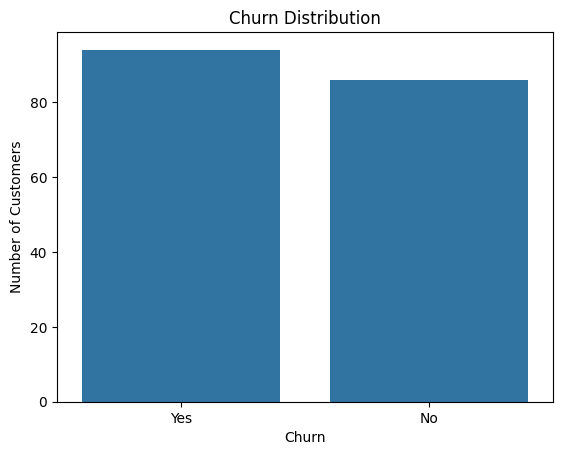

In [69]:
sns.countplot(data=df_cleaned, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [70]:
contract_churn = pd.crosstab(
    df_cleaned["Contract_Type"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract_Type,,
1 Year,53.846154,46.153846
2 Year,79.166667,20.833333
Monthly,37.500000,62.500000


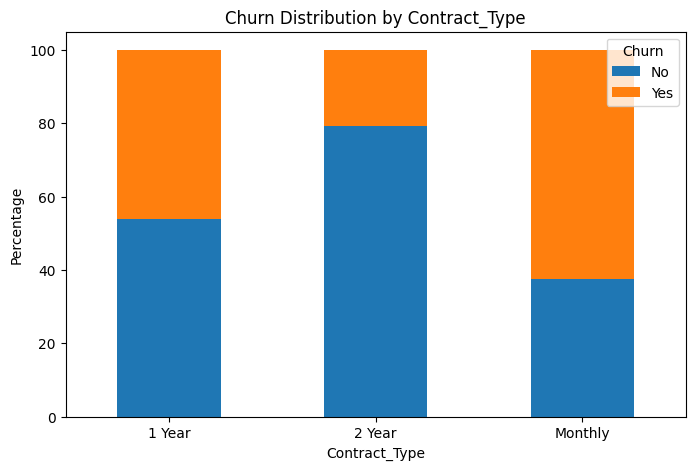

In [71]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Distribution by Contract_Type")
plt.xlabel("Contract_Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

In [72]:
df_cleaned.groupby("Churn")["Satisfaction_Score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,6.302326,6.5,1.0,10.0
Yes,5.265957,5.0,1.0,10.0


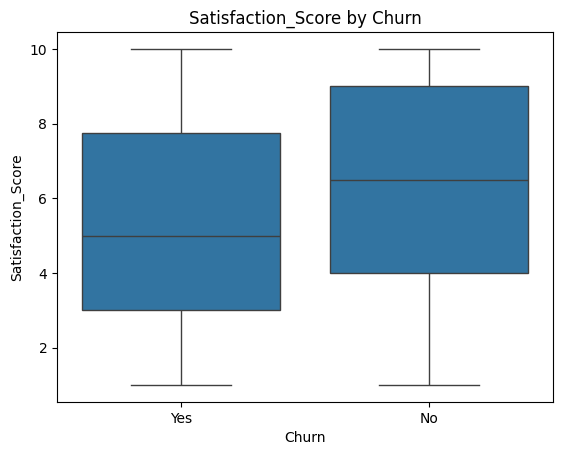

In [73]:
sns.boxplot(
    data=df_cleaned,
    x="Churn",
    y="Satisfaction_Score"
)

plt.title("Satisfaction_Score by Churn")
plt.xlabel("Churn")
plt.ylabel("Satisfaction_Score")
plt.show()

In [74]:
df_cleaned.groupby("Churn")["Tenure_Months"].agg(
    ["mean", "median", "min", "max"]
)


,mean,median,min,max
Churn,,,,
No,36.627907,38.0,1.0,71.0
Yes,40.457447,38.0,1.0,72.0


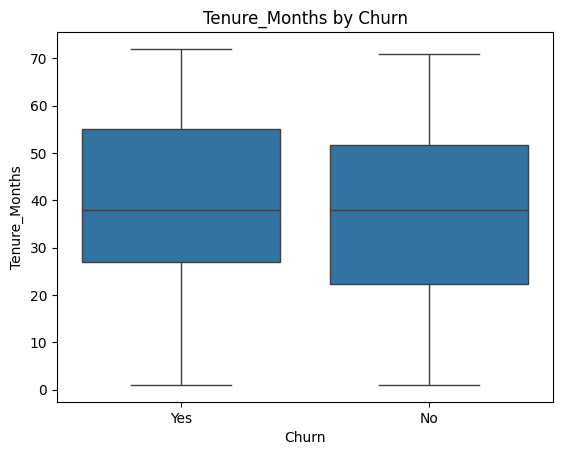

In [75]:
sns.boxplot(
    data=df_cleaned,
    x="Churn",
    y="Tenure_Months"
)

plt.title("Tenure_Months by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure_Months")
plt.show()

In [76]:
df_cleaned.groupby("Churn")["Monthly_Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,72.649767,72.9,0.00,140.55
Yes,76.208723,72.9,26.23,151.18


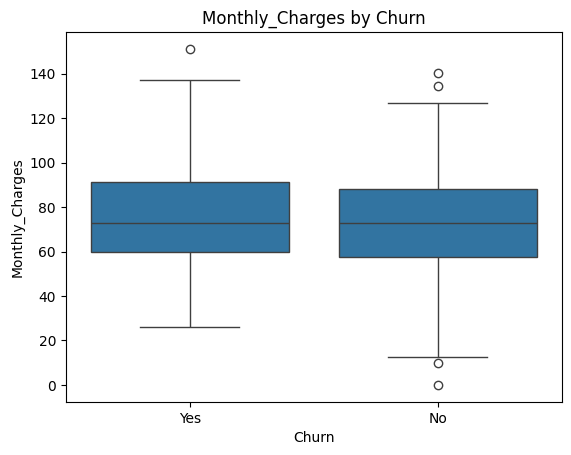

In [77]:
sns.boxplot(
    data=df_cleaned,
    x="Churn",
    y="Monthly_Charges"
)

plt.title("Monthly_Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly_Charges")
plt.show()

In [78]:
plan_churn = pd.crosstab(
    df_cleaned["Plan_Type"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

plan_churn

Churn,No,Yes
Plan_Type,,
Basic,31.914894,68.085106
Premium,53.846154,46.153846
Standard,53.191489,46.808511


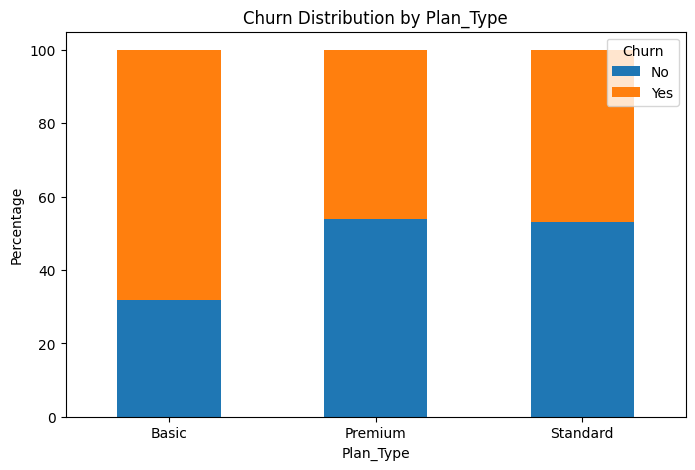

In [79]:
plan_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Distribution by Plan_Type")
plt.xlabel("Plan_Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

In [80]:
payment_churn = pd.crosstab(
    df_cleaned["Payment_Method"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
Payment_Method,,
Bank Transfer,47.826087,52.173913
Credit Card,40.909091,59.090909
Debit Card,51.219512,48.780488
UPI,50.000000,50.000000
Unknown,100.000000,0.000000


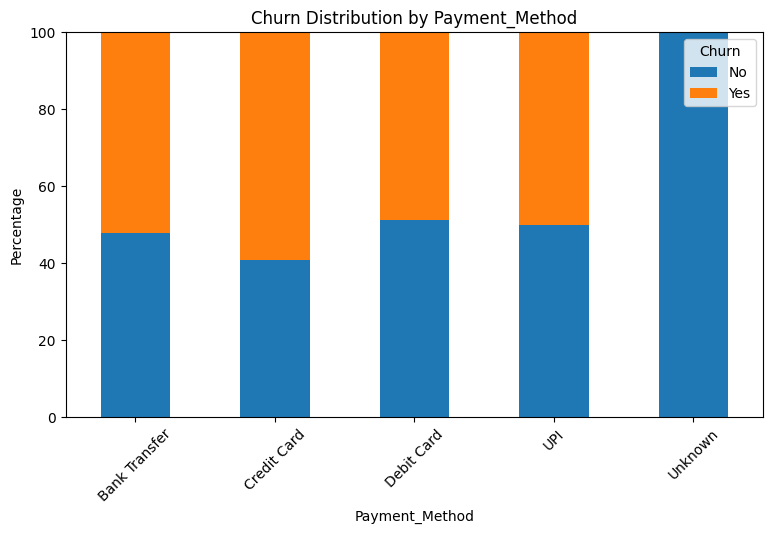

In [81]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Churn Distribution by Payment_Method")
plt.xlabel("Payment_Method")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

In [82]:
region_churn = pd.crosstab(
    df_cleaned["Region"],
    df_cleaned["Churn"],
    normalize="index"
) * 100

region_churn

Churn,No,Yes
Region,,
East,47.058824,52.941176
North,41.176471,58.823529
South,48.979592,51.020408
West,54.347826,45.652174


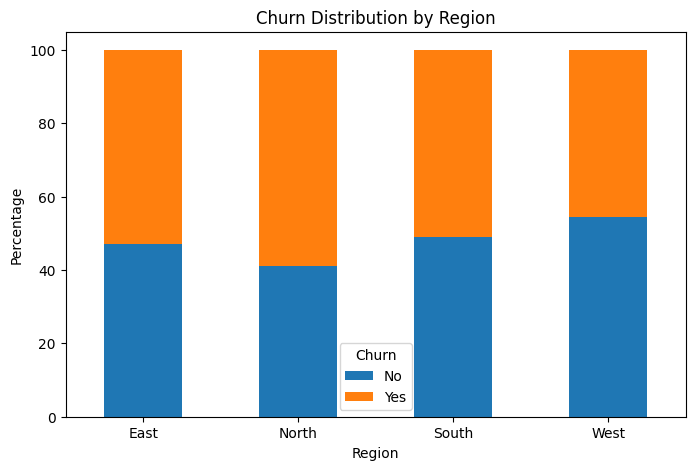

In [83]:
region_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

In [84]:
df_cleaned.groupby("Churn")["Support_Calls_Last_3M"].agg(
    ["mean", "median"]
)

,mean,median
Churn,,
No,2.953488,3.0
Yes,3.148936,3.0


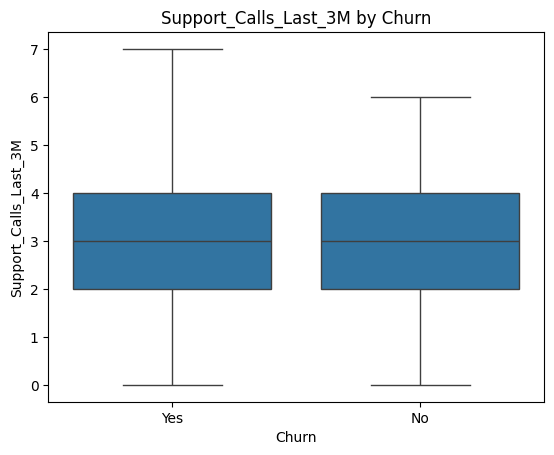

In [85]:
sns.boxplot(
    data=df_cleaned,
    x="Churn",
    y="Support_Calls_Last_3M"
)

plt.title("Support_Calls_Last_3M by Churn")
plt.xlabel("Churn")
plt.ylabel("Support_Calls_Last_3M")
plt.show()

In [86]:
df_cleaned.groupby("Churn")["Data_Usage_GB"].agg(
    ["mean", "median"]
)

,mean,median
Churn,,
No,17.116279,18.40
Yes,20.086170,18.85


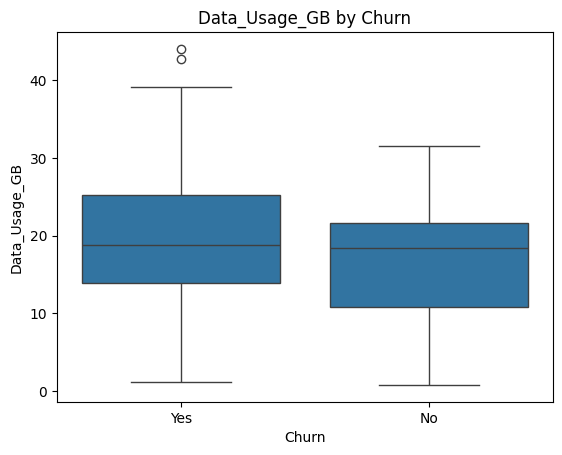

In [87]:
sns.boxplot(
    data=df_cleaned,
    x="Churn",
    y="Data_Usage_GB"
)

plt.title("Data_Usage_GB by Churn")
plt.xlabel("Churn")
plt.ylabel("Data_Usage_GB")
plt.show()

In [88]:
df_cleaned.groupby("Churn")[
    [
        "Age",
        "Annual_Income",
        "Tenure_Months",
        "Monthly_Charges",
        "Support_Calls_Last_3M",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].mean()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Churn,,,,,,,
No,35.802326,64223.255814,36.627907,72.649767,2.953488,17.116279,6.302326
Yes,36.776596,66071.276596,40.457447,76.208723,3.148936,20.086170,5.265957


In [89]:
correlation = df_cleaned[
    [
        "Age",
        "Annual_Income",
        "Tenure_Months",
        "Monthly_Charges",
        "Support_Calls_Last_3M",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].corr()

correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.037504,0.038427,-0.012847,0.018897,0.039063,-0.076507
Annual_Income,0.037504,1.000000,0.006397,-0.015068,0.035998,-0.073628,0.080861
Tenure_Months,0.038427,0.006397,1.000000,0.007364,-0.046458,0.016972,-0.019388
Monthly_Charges,-0.012847,-0.015068,0.007364,1.000000,-0.012933,0.004198,0.033099
Support_Calls_Last_3M,0.018897,0.035998,-0.046458,-0.012933,1.000000,-0.053334,0.034348
Data_Usage_GB,0.039063,-0.073628,0.016972,0.004198,-0.053334,1.000000,0.048394
Satisfaction_Score,-0.076507,0.080861,-0.019388,0.033099,0.034348,0.048394,1.000000


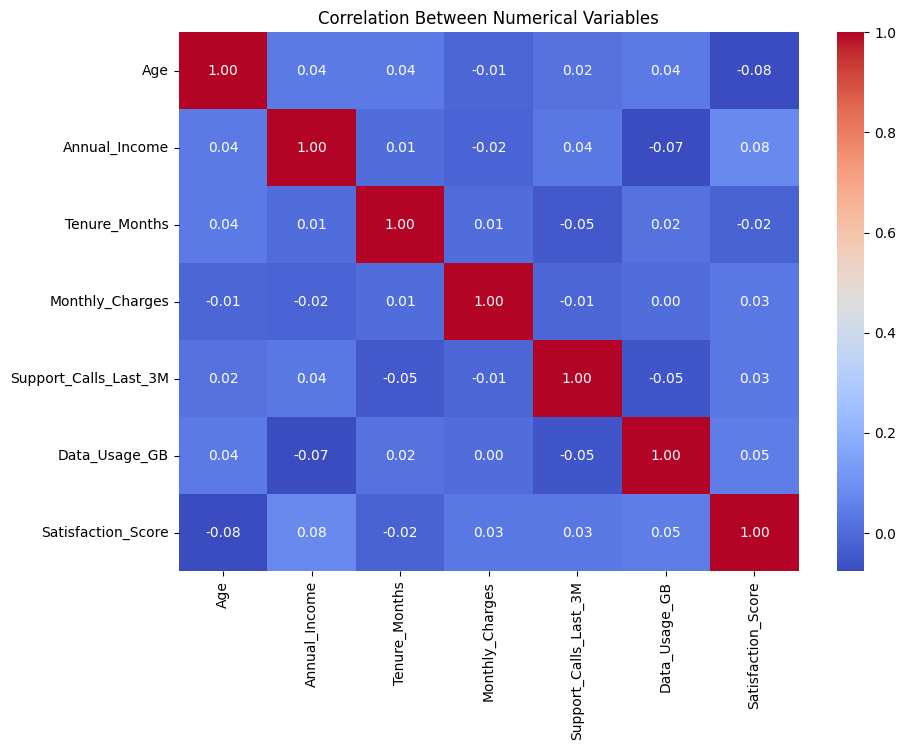

In [90]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

#### 5. Feature Engineering and Preprocessing

In [91]:
df_model = df_cleaned.drop(columns=["Customer_ID"])

In [92]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

In [93]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 11)
y shape: (180,)


In [94]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [95]:
y.value_counts()

Churn
1    94
0    86
Name: count, dtype: int64

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [97]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numerical_columns])

X_test_scaled = scaler.transform(X_test[numerical_columns])

In [99]:
X_train_scaled[:5]

array([[-0.70753114, -0.00383732, -1.77297325,  1.95450729,  0.        ,
         1.00210382, -0.94467822],
       [ 0.19710357,  0.83198858,  0.66579115, -0.15870199, -1.2579418 ,
         1.26436445, -1.30551022],
       [-0.02905511, -0.86288061, -1.21408974,  1.81407966,  1.2579418 ,
         0.08419162,  1.22031378],
       [-0.48137246,  1.21739719, -0.04551513, -0.72720738,  0.        ,
        -1.03637652,  0.85948178],
       [ 0.31018291,  0.16332786,  0.10690764, -0.81403091,  0.6289709 ,
        -1.48937215,  0.49864978]])

In [100]:
X_train_scaled = scaler.fit_transform(X_train[numerical_columns])

In [101]:
X_test_scaled = scaler.transform(X_test[numerical_columns])

In [102]:

X_train_scaled.mean(axis=0)


array([ 1.85037171e-16, -8.32667268e-17, -1.40319855e-16, -1.97372982e-16,
        3.08395285e-18, -6.16790569e-17,  5.85951041e-17])

In [103]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1.])

In [104]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

In [105]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

In [106]:
X_train_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 576 stored elements and shape (144, 15)>

In [107]:
encoder.get_feature_names_out(categorical_columns)

array(['Contract_Type_1 Year', 'Contract_Type_2 Year',
       'Contract_Type_Monthly', 'Payment_Method_Bank Transfer',
       'Payment_Method_Credit Card', 'Payment_Method_Debit Card',
       'Payment_Method_UPI', 'Payment_Method_Unknown', 'Region_East',
       'Region_North', 'Region_South', 'Region_West', 'Plan_Type_Basic',
       'Plan_Type_Premium', 'Plan_Type_Standard'], dtype=object)

In [108]:
X_train_encoded_df = pd.DataFrame(
    X_train_encoded.toarray(),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

X_train_encoded_df.head()

,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,Payment_Method_Bank Transfer,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
92,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
148,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
93,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
16,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
62,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [109]:
X_test_encoded_df = pd.DataFrame(
    X_test_encoded.toarray(),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_test_encoded_df.head()

,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,Payment_Method_Bank Transfer,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
180,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
15,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
69,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
174,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
118,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [111]:
x_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [112]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [114]:
handle_unknown="ignore"

In [115]:
df_cleaned.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [116]:
X_train_processed = preprocessor.fit_transform(X_train)

In [117]:
X_test_processed = preprocessor.transform(X_test)

In [118]:
print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (144, 22)
X_test shape: (36, 22)
y_train shape: (144,)
y_test shape: (36,)


In [119]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### 6 & 7 -  Build Multiple Supervised Learning Models & Model evaluation

#### Logistic Regression

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [121]:
X = df_cleaned.drop(columns=["Customer_ID", "Churn"])

y = df_cleaned["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [123]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [125]:
model = LogisticRegression(max_iter=1000)

In [126]:
model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [127]:
y_pred = model.predict(X_test_processed)

In [128]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

In [129]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("LOGISTIC REGRESSION")

print("\nAccuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)



LOGISTIC REGRESSION

Accuracy: 0.5833333333333334
Precision: 0.625
Recall: 0.5263157894736842
F1 Score: 0.5714285714285714


In [130]:
cm = confusion_matrix(y_test, y_pred)
print("\nconfusion Matrix:")
print(cm)



confusion Matrix:
[[11  6]
 [ 9 10]]


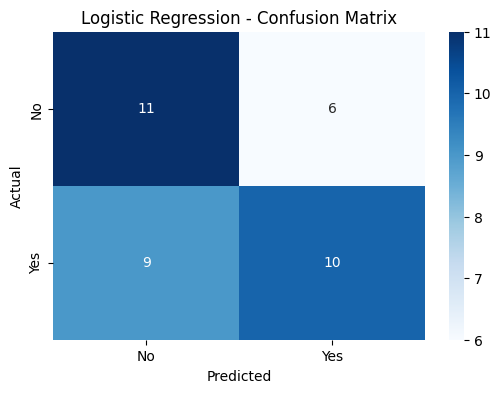

In [131]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [132]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

Classification Report:
              precision    recall  f1-score   support

          No       0.55      0.65      0.59        17
         Yes       0.62      0.53      0.57        19

    accuracy                           0.58        36
   macro avg       0.59      0.59      0.58        36
weighted avg       0.59      0.58      0.58        36



In [133]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

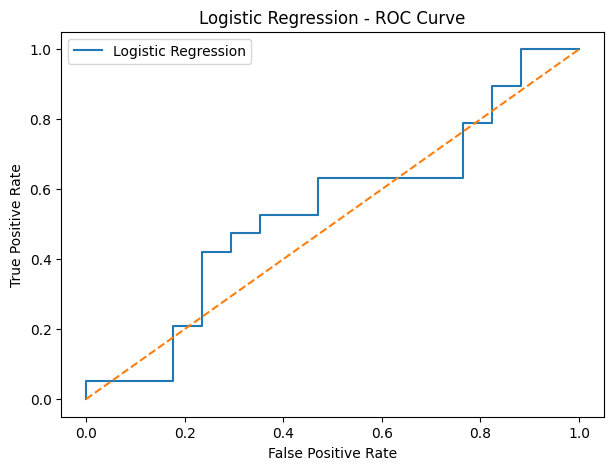

In [134]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")

plt.legend()
plt.show()

In [135]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5386996904024768


#### KNN

In [136]:
X = df_cleaned.drop(columns=["Customer_ID", "Churn"])

y = df_cleaned["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [138]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


In [139]:
model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [140]:
y_pred = model.predict(X_test_processed)

In [141]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

In [142]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)





Accuracy: 0.5833333333333334
Accuracy (%): 58.333333333333336
Precision: 0.625
Recall: 0.5263157894736842
F1 Score: 0.5714285714285714


In [143]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  6]
 [ 9 10]]


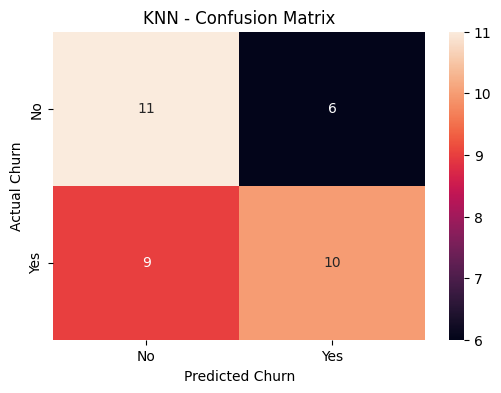

In [144]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.title("KNN - Confusion Matrix")

plt.show()

In [145]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.55      0.65      0.59        17
         Yes       0.62      0.53      0.57        19

    accuracy                           0.58        36
   macro avg       0.59      0.59      0.58        36
weighted avg       0.59      0.58      0.58        36



In [146]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5386996904024768


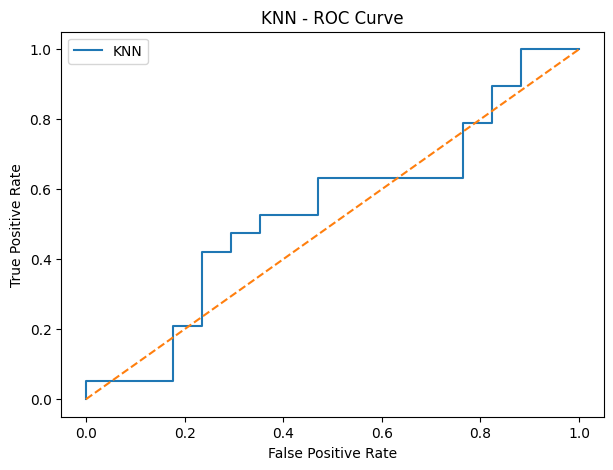

In [147]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="KNN"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN - ROC Curve")

plt.legend()
plt.show()

#### Decision Tree

In [148]:
model = DecisionTreeClassifier(
    random_state=42
)

In [149]:
model.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [150]:
y_pred = model.predict(X_test_processed)

In [151]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

In [152]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

Accuracy: 0.5277777777777778
Accuracy (%): 52.77777777777778
Precision: 0.5714285714285714
Recall: 0.42105263157894735
F1 Score: 0.48484848484848486


In [153]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  6]
 [11  8]]


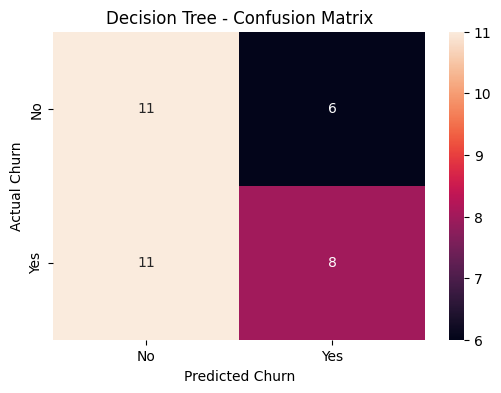

In [154]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [155]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.65      0.56        17
         Yes       0.57      0.42      0.48        19

    accuracy                           0.53        36
   macro avg       0.54      0.53      0.52        36
weighted avg       0.54      0.53      0.52        36



In [156]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5340557275541795


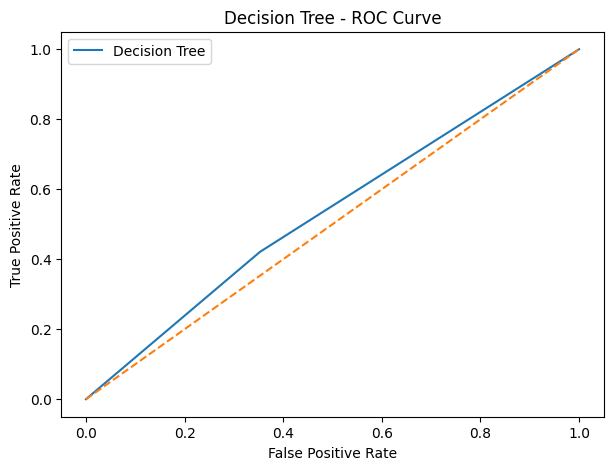

In [157]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Decision Tree"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")

plt.legend()
plt.show()

#### Random Forest

In [158]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [159]:
model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [160]:
y_pred = model.predict(X_test_processed)

In [161]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

In [162]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

Accuracy: 0.5833333333333334
Accuracy (%): 58.333333333333336
Precision: 0.625
Recall: 0.5263157894736842
F1 Score: 0.5714285714285714


In [163]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  6]
 [ 9 10]]


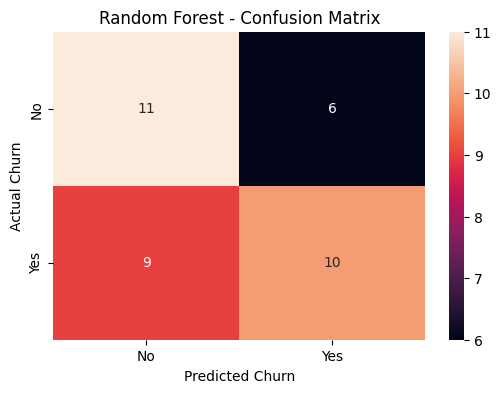

In [164]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [165]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.55      0.65      0.59        17
         Yes       0.62      0.53      0.57        19

    accuracy                           0.58        36
   macro avg       0.59      0.59      0.58        36
weighted avg       0.59      0.58      0.58        36



In [166]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6068111455108359


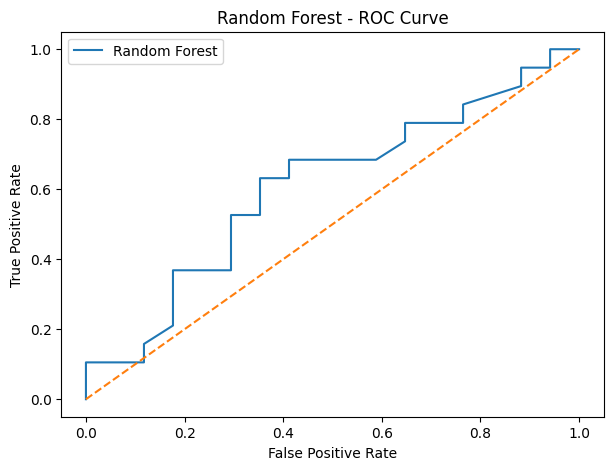

In [167]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()
plt.show()

#### AdaBoost

In [168]:
model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [169]:
model.fit(X_train_processed, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [170]:
y_pred = model.predict(X_test_processed)

In [171]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

In [172]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

Accuracy: 0.5555555555555556
Accuracy (%): 55.55555555555556
Precision: 0.6153846153846154
Recall: 0.42105263157894735
F1 Score: 0.5


In [173]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  5]
 [11  8]]


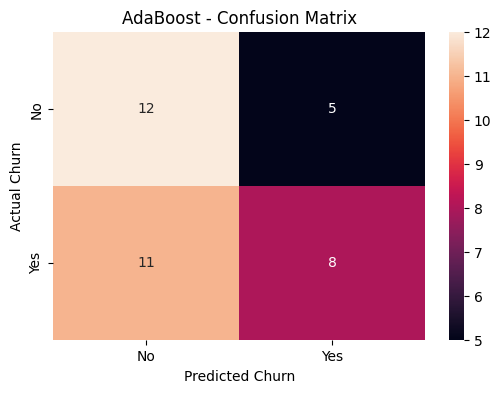

In [174]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")
plt.title("AdaBoost - Confusion Matrix")

plt.show()

In [175]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)

Classification Report:
              precision    recall  f1-score   support

          No       0.52      0.71      0.60        17
         Yes       0.62      0.42      0.50        19

    accuracy                           0.56        36
   macro avg       0.57      0.56      0.55        36
weighted avg       0.57      0.56      0.55        36



In [176]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5696594427244582


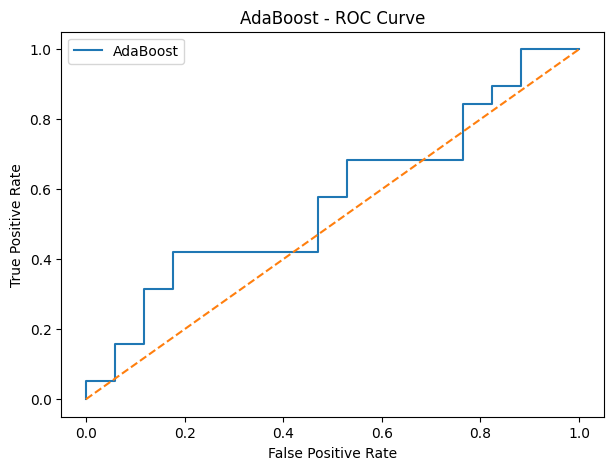

In [177]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="AdaBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost - ROC Curve")

plt.legend()
plt.show()

#### 8 & 9 - Cross-validation & Model comparison

In [178]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

model = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    )
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, algorithm in model.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", algorithm)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1"
        }
    )

    results.append({
        "Algorithm": name,
        "CV Score": scores["test_accuracy"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean()
    })


results_df = pd.DataFrame(results)

results_df

,Algorithm,CV Score,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.594444,0.594444,0.601111,0.649708,0.622201
1,KNN,0.505556,0.505556,0.532527,0.467836,0.493326
2,Decision Tree,0.605556,0.605556,0.627038,0.616374,0.620060
3,Random Forest,0.611111,0.611111,0.615789,0.681287,0.645405
4,AdaBoost,0.583333,0.583333,0.599560,0.628070,0.611660


#### Matrix for Selected Model

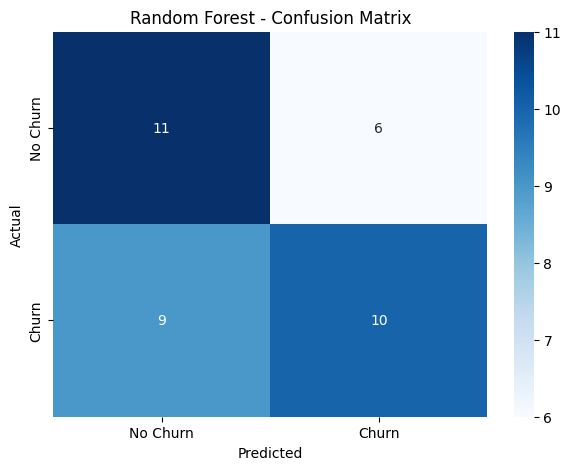

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_pipeline.fit(X_train, y_train)


y_pred = random_forest_pipeline.predict(X_test)


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

#### 10. Final Model


The final model selected is "Random Forest".

The model was selected based on the business objective of identifying customers who are likely to churn.

Random Forest achieved:

- CV Score:0.611111
- Accuracy:0.611111
- Precision:0.615789
- Recall:0.681287
- F1 Score:0.645405

Random Forest has the highest Recall and F1 Score among the models tested. Since identifying customers who may churn is important, Recall is useful because it shows how many of the actual churn customers were correctly identified.

The model was not selected only because of its Accuracy. The decision was based on the overall validation and testing results, especially Recall and F1 Score.



## Why this model was selected

Random Forest was selected because it provides a good balance between Precision and Recall.

Its Recall is "0.681287", which means the model correctly identifies a relatively large number of customers who actually churn.

Its F1 Score is 0.645405**, showing a balance between Precision and Recall.

The cross-validation score is "0.611111", which was used to check the model's performance across different parts of the data.


## Important Features

The important features should be obtained from the trained Random Forest model using feature importance.

The features that have higher importance values have a greater contribution to the model's predictions.

The important features are : 

Age

Annual_Income

RTenure_Months

Monthly_Charges

Support_Calls_Last_3M

Data_Usage_GB

Satisfaction_Score

Contract_Type

Payment_Method

Region

Plan_Type

#### What types of errors the model makes

The Random Forest model can make two main types of errors:

False Positive (FP): The model predicts Churn, but the customer actually does not churn.
False Negative (FN): The model predicts No Churn, but the customer actually churns.

#### How the business could use the predictions

1.Identify customers who are predicted to Churn.

2.Contact these customers and understand their concerns.

3.Provide suitable offers or support to encourage them to stay.

4.Give priority to customers with a higher risk of churn.

5.Monitor customer behavior after taking retention actions.

6.Use the prediction results to improve future customer retention strategies.

#### 11. Business Recommendations
1.Contact customers predicted as Churn and provide suitable retention support before they leave.

2.Focus on customers with low satisfaction by improving their service experience and resolving their issues quickly.

3.Monitor customers with frequent support calls and identify the problems causing repeated support requests.

4.Pay attention to customers with shorter tenure and provide better onboarding and early-stage support.

5.Review monthly charges and plan types for customers predicted to churn and consider suitable plans or offers based on their needs.

#### Example Output Questions

####  1. Which customer segment appears most associated with churn?

Customers who have low satisfaction, shorter tenure, frequent support calls, higher monthly charges, or certain contract/plan types can be examined for higher churn. The exact segment should be identified from the EDA results rather than assumed.

#### 2. What customer characteristics should the retention team monitor?

The retention team should monitor:

Satisfaction_Score
Tenure_Months
Support_Calls_Last_3M
Monthly_Charges
Contract_Type
Plan_Type
Payment_Method
Region
Age
Annual_Income
Data_Usage_GB

#### 3. How should false negatives and false positives be treated?
False Negative: The customer is predicted as No Churn, but actually churns. These should be monitored carefully because the business may miss an opportunity to retain the customer.
False Positive: The customer is predicted as Churn, but actually does not churn. These may lead to unnecessary retention efforts or offers.

#### 4. How could the model be improved with additional data?

The model could be improved by adding more useful customer information, such as:

1.Customer service interaction history
2.Previous complaints
3.Previous retention offers
4.Customer payment history
5.Contract renewal history
6.Customer feedback
7.Reasons for cancellation
8.Previous changes in plans
9.Detailed usage history

#### 5. What happens when the model gives a False Positive?

A False Positive happens when the model predicts Churn, but the customer actually does not churn. The business may spend extra time, money, or offers trying to retain that customer.

#### 6. How can the churn prediction model be improved?

The model could be improved by adding more useful customer data such as customer complaints, service interaction history, payment history, contract renewal history, customer feedback, and reasons for cancellation. More relevant data can help the model identify churn patterns better.

#### Business Insights 

1.Customers predicted as Churn should be contacted early and given suitable retention support.

2.Customers with low Satisfaction_Score should be monitored closely, as improving their service experience may help reduce churn.

3.Customers with high Support_Calls_Last_3M should be monitored, because repeated support requests can indicate customer problems that need attention.

4.Customers with shorter Tenure_Months should receive better onboarding and early support to improve their experience.


5.Monthly_Charges and Plan_Type should be monitored for customers predicted as Churn, so the business can review whether their current plans are suitable for their needs.

#### Conclusion 

Random Forest was selected as the final model based on the validation and testing results. It achieved an Accuracy of 0.611111, Precision of 0.615789, Recall of 0.681287, and F1 Score of 0.645405. The model can help the business identify customers who are likely to churn and take suitable retention actions. 

#### Limitations

The model does not make perfect predictions, so it can produce False Positives and False Negatives. 

Its performance can also be improved by adding more useful customer data, such as customer complaints, service interaction history, payment history, contract renewal history, customer feedback, and reasons for cancellation.
